In [1]:
import pandas as pd
import numpy as np

dataset = pd.read_csv("queue_data.csv")
# Add two empty columns
dataset['service_type'] = ""
dataset['service_details'] = ""
dataset.head()

,arrival_time,start_time,finish_time,wait_time,queue_length,service_type,service_details
0,30-03-2023 0.10,30-03-2023 0.10,2023-03-30 00:22:44.800000000,12.68,28,,
1,30-03-2023 0.10,30-03-2023 0.16,2023-03-30 00:25:53.200000000,9.82,28,,
2,30-03-2023 0.10,30-03-2023 0.16,2023-03-30 00:25:48.400000000,9.74,28,,
3,30-03-2023 0.10,30-03-2023 0.14,2023-03-30 00:27:23.200000000,13.32,28,,
4,30-03-2023 0.10,30-03-2023 0.15,2023-03-30 00:31:21.400000000,16.29,28,,


In [2]:
from datetime import datetime, timedelta

def generate_realistic_synthetic_data(n_samples=1000, start_date='2023-03-31', days=30):
    np.random.seed(42)
    
    # Service durations (2-minute range)
    service_durations = {
        'beard': (9, 11),
        'haircut': (14, 16),  
        'beard and haircut': (24, 26),
        'small car': (22, 24),
        'big car': (29, 31),
        'oil change': (19, 21)
    }
    
    # Service mappings
    service_mapping = {
        'beard': 'barber', 'haircut': 'barber', 'beard and haircut': 'barber',
        'small car': 'car wash', 'big car': 'car wash', 
        'oil change': 'workshop'
    }
    
    data = []
    start_dt = datetime.strptime(start_date, '%Y-%m-%d')
    
    samples_per_day = n_samples // days
    
    for day in range(days):
        current_date = start_dt + timedelta(days=day)
        
        # Generate realistic business day with sequential arrivals
        business_hours = list(range(8, 21))  # 8 AM to 9 PM
        daily_customers = samples_per_day
        
        # Track the actual queue state throughout the day
        current_time = current_date.replace(hour=8, minute=0, second=0)
        queue = []  # List of (arrival_time, service_type, service_detail, service_duration)
        
        for customer in range(daily_customers):
            # Realistic arrival pattern - more customers during peak hours
            hour = current_time.hour
            if 8 <= hour <= 10 or 17 <= hour <= 19:  # Peak hours
                time_gap = np.random.randint(5, 15)  # 5-15 minutes between arrivals
            else:
                time_gap = np.random.randint(10, 30)  # 10-30 minutes between arrivals
            
            arrival_time = current_time + timedelta(minutes=time_gap)
            current_time = arrival_time
            
            # Skip if beyond business hours
            if arrival_time.hour >= 21:
                break
            
            # Random service details
            service_detail = np.random.choice(list(service_durations.keys()))
            service_type = service_mapping[service_detail]
            service_time = np.random.uniform(*service_durations[service_detail])
            
            # Add customer to queue
            queue.append((arrival_time, service_type, service_detail, service_time))
            
            # Calculate wait time based on actual queue position
            staff_count = 2.5
            queue_position = len(queue)
            
            # Estimate wait time: sum of service times for customers ahead / staff_count
            wait_time = sum([q[3] for q in queue[:queue_position]]) / staff_count
            
            # Calculate actual service timeline
            start_time = arrival_time + timedelta(minutes=wait_time)
            finish_time = start_time + timedelta(minutes=service_time)
            
            data.append({
                'arrival_time': arrival_time,
                'start_time': start_time,
                'finish_time': finish_time,
                'wait_time': round(wait_time, 2),
                'queue_length': queue_position,  # This is their position in line
                'service_type': service_type,
                'service_details': service_detail,
                'arrival_hour': arrival_time.hour
            })
            
            # Remove finished customers from queue
            # Customers finish when current_time reaches their finish_time
            queue = [q for q in queue if q[0] + timedelta(minutes=wait_time + service_time) > current_time]
    
    return pd.DataFrame(data)

# Generate realistic data
realistic_data = generate_realistic_synthetic_data(1000, '2023-03-31', 30)
dataset = pd.concat([dataset, realistic_data], ignore_index=True)




In [3]:
# remove the duplicate on the datasets
dataset = dataset.drop_duplicates()

In [4]:
#check if there is an empty colums that contain Nan
print(dataset.isnull().sum())

arrival_time         0
start_time           0
finish_time          0
wait_time            0
queue_length         0
service_type         0
service_details      0
arrival_hour       559
dtype: int64


In [5]:
# Make a explicit copy first
dataset = dataset.copy()

# Then do your datetime conversions
dataset['arrival_time'] = pd.to_datetime(dataset['arrival_time'], format='%d-%m-%Y %H.%M')
dataset['start_time'] = pd.to_datetime(dataset['start_time'], format='%d-%m-%Y %H.%M')
dataset['finish_time'] = pd.to_datetime(dataset['finish_time'])

print("Arrival time samples:")
print(dataset['arrival_time'].head(3))
print("\nStart time samples:") 
print(dataset['start_time'].head(3))
print("\nFinish time samples:")
print(dataset['finish_time'].head(3))


Arrival time samples:
0   2023-03-30 00:10:00
1   2023-03-30 00:10:00
2   2023-03-30 00:10:00
Name: arrival_time, dtype: datetime64[ns]

Start time samples:
0   2023-03-30 00:10:00
1   2023-03-30 00:16:00
2   2023-03-30 00:16:00
Name: start_time, dtype: datetime64[ns]

Finish time samples:
0   2023-03-30 00:22:44.800
1   2023-03-30 00:25:53.200
2   2023-03-30 00:25:48.400
Name: finish_time, dtype: datetime64[ns]


In [6]:
#checks the wait time information and if there is an outlier
print("Wait time statistics:")
print(dataset['wait_time'].describe())

high_waits = dataset[dataset['wait_time'] > 240]  # 240 minutes = 4 hours
print(f"\nWait times over 4 hours: {len(high_waits)}")

Wait time statistics:
count    1549.000000
mean       53.331007
std        51.211433
min        -2.930000
25%        12.050000
50%        33.680000
75%        84.720000
max       204.220000
Name: wait_time, dtype: float64

Wait times over 4 hours: 0


In [7]:
dataset['arrival_hour'] = dataset['arrival_time'].dt.hour

In [8]:
# def custom_peak_hours(hour):
#     # Based on YOUR data - 9AM to 1PM is your real rush!
#     return 1 if 9 <= hour <= 13 else 0

# dataset['is_peak_hour'] = dataset['arrival_hour'].apply(custom_peak_hours)
dataset['actual_service_duration'] = (dataset['finish_time'] - dataset['start_time']).dt.total_seconds() / 60
dataset['start_hour'] = dataset['start_time'].dt.hour


Feature Engineering 

In [9]:
"""
what is does it put customres in order by there arrival time and group them by service time and details and for each customre sees the customre before him 
and then we calcute the avg for these people
"""

dataset = dataset.sort_values('arrival_time').reset_index(drop=True)
dataset['avg_service_time'] = dataset.groupby(['service_type', 'service_details'])['actual_service_duration']\
    .expanding()\
    .mean()\
    .shift(1)\
    .reset_index(level=[0, 1], drop=True)
dataset['avg_service_time'] = dataset['avg_service_time'].fillna(dataset['actual_service_duration'].median())

In [ ]:
"""
what it does it put the service in time order and group them by the time 8 and 9 until last hour and then for each time it can only look at the one before 
with the same time and then calculate the average from the one before and then use the average before and for the first one it has nothing before it 
"""


dataset = dataset.sort_values('arrival_time').reset_index(drop=True)


dataset['hourly_avg_service_time'] = dataset.groupby('start_hour')['actual_service_duration']\
    .expanding()\
    .mean()\
    .shift(1)\
    .reset_index(level=0, drop=True)


dataset['hourly_avg_service_time'] = dataset['hourly_avg_service_time'].fillna(dataset['actual_service_duration'].median())

In [12]:
# Fill service_type directly
service_types = ['barber', 'car wash', 'workshop']
probabilities = [0.4, 0.4, 0.2]

dataset['service_type'] = np.random.choice(service_types, size=len(dataset), p=probabilities)

# Fill service_details directly based on service_type
dataset['service_details'] = 'oil change'  # Default for workshop
dataset.loc[dataset['service_type'] == 'barber', 'service_details'] = np.random.choice(
    ['haircut', 'beard', 'beard and haircut'], 
    size=len(dataset[dataset['service_type'] == 'barber']),
    p=[0.5, 0.3, 0.2]
)
dataset.loc[dataset['service_type'] == 'car wash', 'service_details'] = np.random.choice(
    ['small car', 'big car'],
    size=len(dataset[dataset['service_type'] == 'car wash']), 
    p=[0.7, 0.3]
)


In [13]:
dataset

,arrival_time,start_time,finish_time,wait_time,queue_length,service_type,service_details,arrival_hour,actual_service_duration,start_hour,avg_service_time,hourly_avg_service_time
0,2023-03-30 00:10:00,2023-03-30 00:10:00.000000,2023-03-30 00:22:44.800000,12.68,28,car wash,small car,0,12.746667,0,15.424541,15.424541
1,2023-03-30 00:10:00,2023-03-30 00:17:00.000000,2023-03-30 00:30:07.600000,13.06,28,car wash,small car,0,13.126667,0,11.071111,12.746667
2,2023-03-30 00:10:00,2023-03-30 00:19:00.000000,2023-03-30 00:25:33.400000,6.49,28,workshop,oil change,0,6.556667,0,11.244744,12.936667
3,2023-03-30 00:10:00,2023-03-30 00:14:00.000000,2023-03-30 00:21:20.800000,7.28,28,car wash,big car,0,7.346667,0,11.400667,10.810000
4,2023-03-30 00:10:00,2023-03-30 00:18:00.000000,2023-03-30 00:22:31.000000,4.45,28,barber,haircut,0,4.516667,0,11.687500,9.944167
...,...,...,...,...,...,...,...,...,...,...,...,...
1544,2023-04-29 13:35:00,2023-04-29 14:59:25.284721,2023-04-29 15:23:24.667678,84.42,10,workshop,oil change,13,23.989716,14,23.021221,19.117418
1545,2023-04-29 13:53:00,2023-04-29 14:50:48.067179,2023-04-29 14:59:58.651383,57.80,7,barber,beard and haircut,13,9.176403,14,9.946865,19.142663
1546,2023-04-29 14:17:00,2023-04-29 15:04:45.210817,2023-04-29 15:24:31.948644,47.75,6,car wash,small car,14,19.778964,15,20.054850,18.174640
1547,2023-04-29 14:39:00,2023-04-29 15:17:15.739963,2023-04-29 15:37:20.708876,38.26,5,barber,beard,14,20.082815,15,20.053227,18.184794


In [ ]:
# spilt the x and y
x = dataset[['arrival_hour','queue_length', 'service_type', 'service_details','avg_service_time','avg_service_time']].values
# # Use these engineered features
y = dataset['wait_time'].values

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder' , OneHotEncoder() , [2,3])], remainder='passthrough')
x =  np.array(ct.fit_transform(x))

In [16]:
# split the code into train and test samples
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(x, y, test_size = 0.2 , random_state = 1)

In [17]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train[:, 9:] = sc.fit_transform(X_train[:, 9:])
X_test[:, 9:] = sc.transform(X_test[:, 9:])

In [18]:
from sklearn.linear_model import LinearRegression
ml_model = LinearRegression()
ml_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [19]:
ml_pred = ml_model.predict(X_test)
np.set_printoptions(precision=2)
print(np.concatenate((ml_pred.reshape(len(ml_pred),1), y_test.reshape(len(y_test),1)),1))

[[ 82.6   92.2 ]
 [ 60.67  61.33]
 [ 89.94 157.91]
 [ 73.41  26.9 ]
 [ 41.61   8.37]
 [ 62.99  92.7 ]
 [ 15.95  15.31]
 [ 44.15  11.43]
 [ 58.6   94.87]
 [ 90.29 189.03]
 [ 12.2    1.82]
 [ 15.48  11.28]
 [ 57.54  20.25]
 [  8.04   7.48]
 [-21.64  12.67]
 [ 40.42 139.57]
 [ 22.6   12.8 ]
 [ 77.1   34.79]
 [ 25.56  17.61]
 [ 13.87   8.55]
 [ 60.93  32.63]
 [ -0.68   7.46]
 [ 60.94  53.47]
 [116.32  16.65]
 [ 10.53  11.3 ]
 [ 25.87   7.06]
 [ 26.46   6.35]
 [112.34 106.72]
 [ 82.37  81.  ]
 [ 53.88  54.72]
 [ 24.67  17.17]
 [ 83.85 115.51]
 [  2.31   7.48]
 [ 56.72 114.64]
 [ 45.2   76.44]
 [ 74.92  82.57]
 [ 53.01 106.67]
 [ 33.79   3.04]
 [ 83.54  84.72]
 [ 12.83  19.7 ]
 [ 54.44 113.45]
 [ 93.16  95.29]
 [ 59.99 116.61]
 [ 28.08  15.4 ]
 [106.94  84.63]
 [109.29 112.65]
 [ 18.76  15.76]
 [ 82.76 126.52]
 [ 32.9    1.82]
 [ 89.15  38.47]
 [ 24.15  13.13]
 [106.47  93.02]
 [ 27.25  12.87]
 [129.37  94.55]
 [ 79.43 126.83]
 [ 93.76 137.21]
 [ 90.02 111.02]
 [ 31.42   6.69]
 [ 25.67   4.3

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import median_absolute_error
ml_mae = mean_absolute_error(y_test, ml_pred)
ml_rmse = np.sqrt(mean_squared_error(y_test, ml_pred))
ml_medae = median_absolute_error(y_test, ml_pred)
print(f"Linear Regression Mean Absolute Error: {ml_mae:.2f} minutes")
print(f"Linear Regression Root Mean Squared Error: {ml_rmse:.2f} minutes")
print(f"Linear Regression Median Absolute Error: {ml_medae:.2f} minutes")

Linear Regression Mean Absolute Error: 30.29 minutes
Linear Regression Root Mean Squared Error: 41.00 minutes
Linear Regression Median Absolute Error: 21.68 minutes


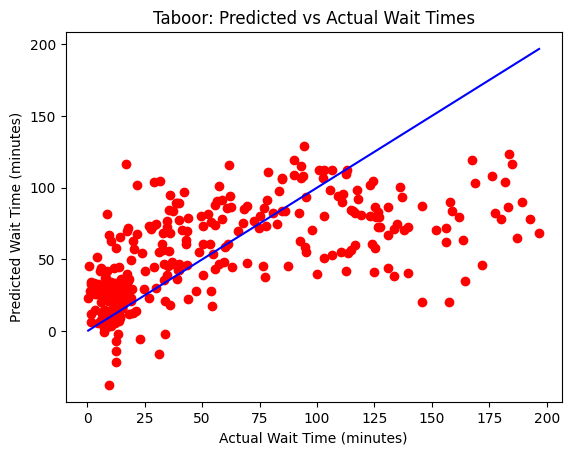

In [21]:
import matplotlib.pyplot as plt
plt.scatter(y_test, ml_pred, color = 'red')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color = 'blue')
plt.title('Taboor: Predicted vs Actual Wait Times')
plt.xlabel('Actual Wait Time (minutes)')
plt.ylabel('Predicted Wait Time (minutes)')
plt.show()

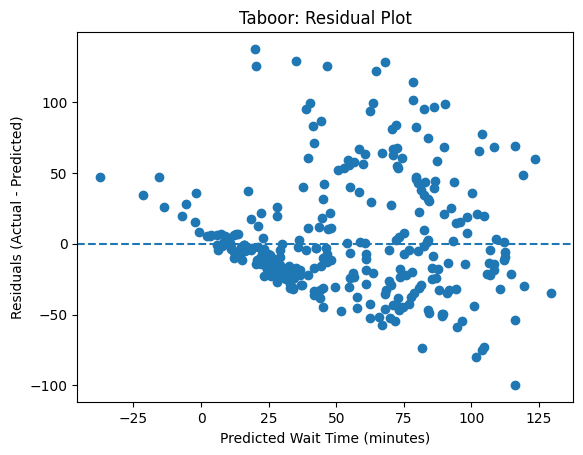

In [23]:
# Residual Plot
residuals = y_test - ml_pred

plt.scatter(ml_pred, residuals)
plt.axhline(y=0, linestyle='--')
plt.title('Taboor: Residual Plot')
plt.xlabel('Predicted Wait Time (minutes)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.show()

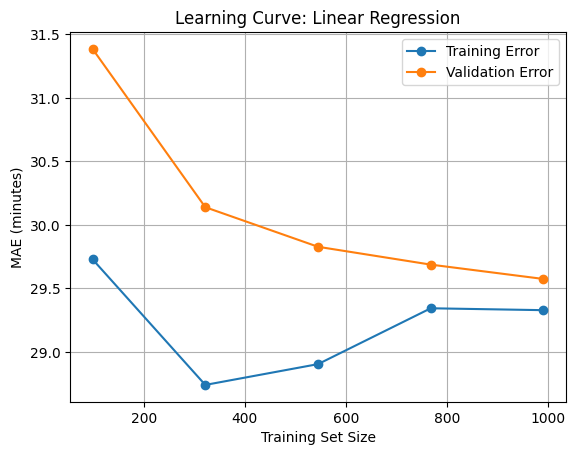

In [28]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    ml_model, X_train, y_train, cv=5,
    scoring='neg_mean_absolute_error'
)

# Convert scores to positive MAE
train_scores_mean = -train_scores.mean(axis=1)
val_scores_mean = -val_scores.mean(axis=1)

plt.plot(train_sizes, train_scores_mean, marker='o', label='Training Error')
plt.plot(train_sizes, val_scores_mean, marker='o', label='Validation Error')
plt.title('Learning Curve: Linear Regression')
plt.xlabel('Training Set Size')
plt.ylabel('MAE (minutes)')
plt.legend()
plt.grid(True)
plt.show()

In [29]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
poly_reg = PolynomialFeatures(degree = 4)
X_poly = poly_reg.fit_transform(X_train)
PL_model = LinearRegression()
PL_model.fit(X_poly, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [30]:
PL_pred = PL_model.predict(poly_reg.transform(X_test))
np.set_printoptions(precision=2)
print(np.concatenate((PL_pred.reshape(len(PL_pred),1), y_test.reshape(len(y_test),1)),1))

[[  79.2    92.2 ]
 [  53.61   61.33]
 [ 161.68  157.91]
 [  33.05   26.9 ]
 [  14.56    8.37]
 [ 101.76   92.7 ]
 [  19.82   15.31]
 [  39.22   11.43]
 [ 121.14   94.87]
 [ 188.31  189.03]
 [  11.34    1.82]
 [ -22.02   11.28]
 [  19.44   20.25]
 [  17.17    7.48]
 [   3.67   12.67]
 [ 127.21  139.57]
 [  12.39   12.8 ]
 [  34.94   34.79]
 [   9.6    17.61]
 [   3.71    8.55]
 [  39.47   32.63]
 [   0.78    7.46]
 [  61.4    53.47]
 [-244.18   16.65]
 [   8.86   11.3 ]
 [  -1.98    7.06]
 [   7.14    6.35]
 [  97.95  106.72]
 [  85.8    81.  ]
 [  58.72   54.72]
 [ -16.     17.17]
 [ 121.36  115.51]
 [  15.85    7.48]
 [ 120.63  114.64]
 [  78.28   76.44]
 [  70.55   82.57]
 [ 105.1   106.67]
 [   5.71    3.04]
 [  95.46   84.72]
 [  17.22   19.7 ]
 [ 125.76  113.45]
 [  86.41   95.29]
 [ 115.68  116.61]
 [  10.03   15.4 ]
 [  94.08   84.63]
 [ 110.21  112.65]
 [ -16.39   15.76]
 [ 127.94  126.52]
 [  -3.38    1.82]
 [  43.02   38.47]
 [  16.43   13.13]
 [  79.11   93.02]
 [  14.31   

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import median_absolute_error
PL_mae = mean_absolute_error(y_test, PL_pred)
PL_rmse = np.sqrt(mean_squared_error(y_test, PL_pred))
PL_medae = median_absolute_error(y_test, PL_pred)
print(f"Polynomial Regression Mean Absolute Error: {PL_mae:.2f} minutes")
print(f"Polynomial Regression Root Mean Squared Error: {PL_rmse:.2f} minutes")
print(f"Polynomial Regression Median Absolute Error: {PL_medae:.2f} minutes")

Polynomial Regression Mean Absolute Error: 10.54 minutes
Polynomial Regression Root Mean Squared Error: 22.74 minutes
Polynomial Regression Median Absolute Error: 6.19 minutes


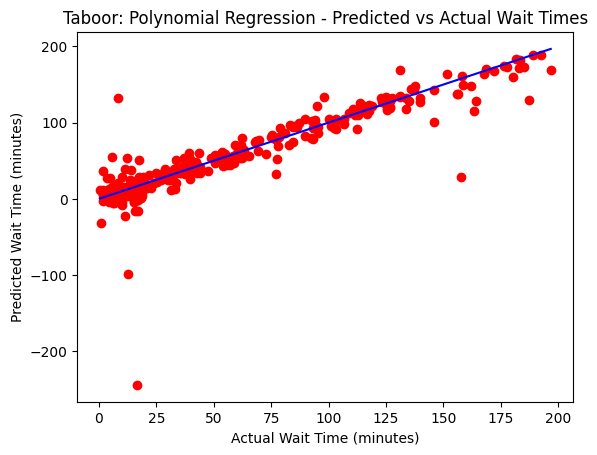

In [32]:
plt.scatter(y_test, PL_pred, color = 'red')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color = 'blue')
plt.title('Taboor: Polynomial Regression - Predicted vs Actual Wait Times')
plt.xlabel('Actual Wait Time (minutes)')
plt.ylabel('Predicted Wait Time (minutes)')
plt.show()

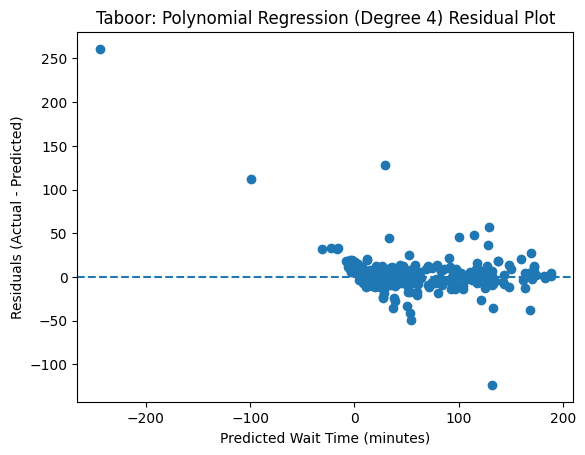

In [33]:
# Residual Plot
residuals = y_test - PL_pred

plt.scatter(PL_pred, residuals)
plt.axhline(y=0, linestyle='--')
plt.title('Taboor: Polynomial Regression (Degree 4) Residual Plot')
plt.xlabel('Predicted Wait Time (minutes)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.show()

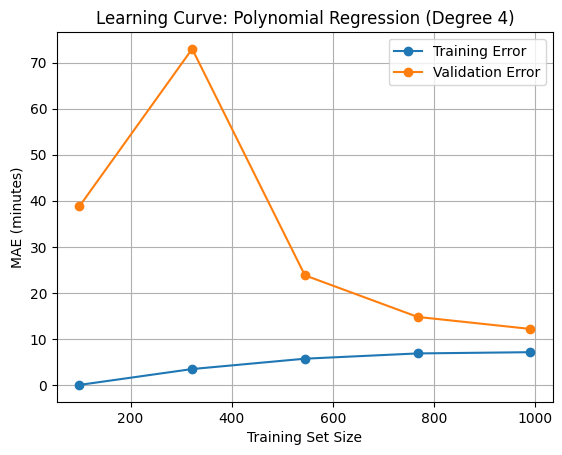

In [34]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    PL_model, poly_reg.fit_transform(X_train), y_train,
    cv=5, scoring='neg_mean_absolute_error'
)

# Convert negative MAE to positive
train_scores_mean = -train_scores.mean(axis=1)
val_scores_mean = -val_scores.mean(axis=1)

plt.plot(train_sizes, train_scores_mean, marker='o', label='Training Error')
plt.plot(train_sizes, val_scores_mean, marker='o', label='Validation Error')
plt.title('Learning Curve: Polynomial Regression (Degree 4)')
plt.xlabel('Training Set Size')
plt.ylabel('MAE (minutes)')
plt.legend()
plt.grid(True)
plt.show()


In [35]:
from sklearn.ensemble import RandomForestRegressor
regressor = RandomForestRegressor(n_estimators = 10, random_state = 0)
regressor.fit(X_train, y_train)

,n_estimators,10
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [36]:
y_pred = regressor.predict(X_test)
np.set_printoptions(precision=2)
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))

[[ 86.13  92.2 ]
 [ 44.78  61.33]
 [157.73 157.91]
 [ 34.84  26.9 ]
 [ 26.49   8.37]
 [ 91.02  92.7 ]
 [  9.04  15.31]
 [ 11.97  11.43]
 [108.74  94.87]
 [188.59 189.03]
 [  8.62   1.82]
 [ 12.56  11.28]
 [ 22.06  20.25]
 [ 11.77   7.48]
 [  9.89  12.67]
 [119.29 139.57]
 [ 11.72  12.8 ]
 [ 36.01  34.79]
 [ 10.7   17.61]
 [  9.54   8.55]
 [ 41.27  32.63]
 [ 12.16   7.46]
 [ 68.6   53.47]
 [ 11.46  16.65]
 [  9.54  11.3 ]
 [  4.75   7.06]
 [  8.06   6.35]
 [107.36 106.72]
 [ 86.01  81.  ]
 [ 55.46  54.72]
 [ 19.53  17.17]
 [108.65 115.51]
 [  9.77   7.48]
 [115.03 114.64]
 [ 73.47  76.44]
 [ 76.36  82.57]
 [107.26 106.67]
 [ 10.41   3.04]
 [ 81.94  84.72]
 [  9.89  19.7 ]
 [118.87 113.45]
 [100.43  95.29]
 [114.7  116.61]
 [  8.43  15.4 ]
 [102.71  84.63]
 [115.9  112.65]
 [  9.54  15.76]
 [133.65 126.52]
 [ 10.94   1.82]
 [ 41.14  38.47]
 [ 11.34  13.13]
 [ 89.45  93.02]
 [ 14.75  12.87]
 [ 95.65  94.55]
 [118.77 126.83]
 [146.56 137.21]
 [105.75 111.02]
 [ 10.46   6.69]
 [ 12.28   4.3

In [37]:
from sklearn.metrics import mean_absolute_error
RF_mae = mean_absolute_error(y_test, y_pred)
RF_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
RF_medae = median_absolute_error(y_test, y_pred)
print(f"Random Forest Mean Absolute Error: {RF_mae:.2f} minutes")
print(f"Random Forest Root Mean Squared Error: {RF_rmse:.2f} minutes")
print(f"Random Forest Median Absolute Error: {RF_medae:.2f} minutes")

Random Forest Mean Absolute Error: 5.69 minutes
Random Forest Root Mean Squared Error: 8.26 minutes
Random Forest Median Absolute Error: 4.15 minutes


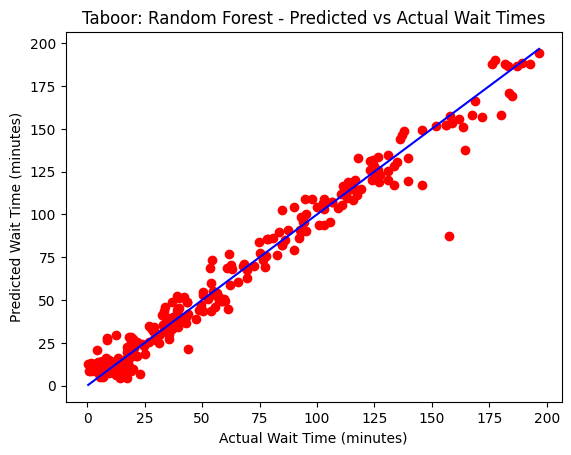

In [38]:
plt.scatter(y_test, y_pred, color = 'red')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color = 'blue')
plt.title('Taboor: Random Forest - Predicted vs Actual Wait Times')
plt.xlabel('Actual Wait Time (minutes)')
plt.ylabel('Predicted Wait Time (minutes)')
plt.show()

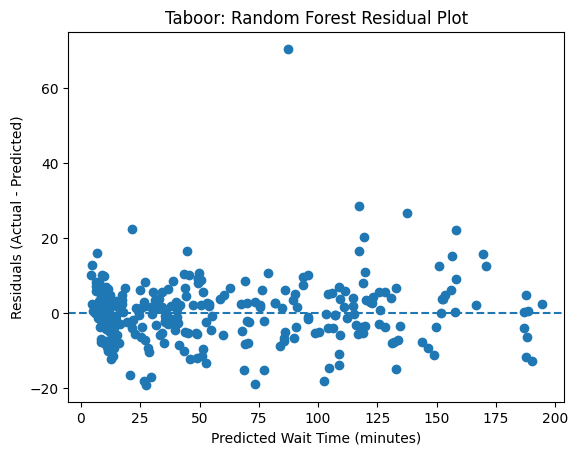

In [39]:
# Residual Plot
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0, linestyle='--')
plt.title('Taboor: Random Forest Residual Plot')
plt.xlabel('Predicted Wait Time (minutes)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.show()

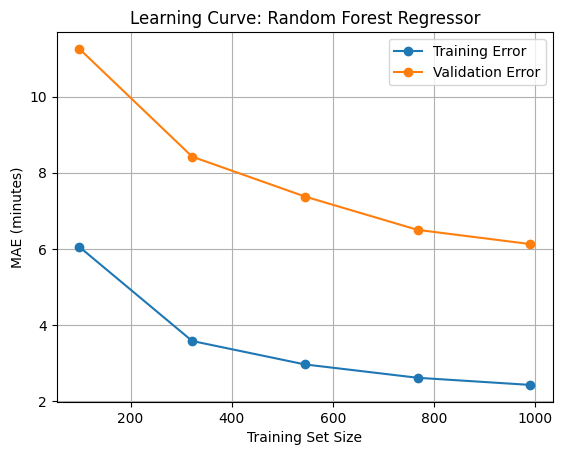

In [40]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    regressor, X_train, y_train,
    cv=5, scoring='neg_mean_absolute_error'
)

train_scores_mean = -train_scores.mean(axis=1)
val_scores_mean = -val_scores.mean(axis=1)

plt.plot(train_sizes, train_scores_mean, marker='o', label='Training Error')
plt.plot(train_sizes, val_scores_mean, marker='o', label='Validation Error')
plt.title('Learning Curve: Random Forest Regressor')
plt.xlabel('Training Set Size')
plt.ylabel('MAE (minutes)')
plt.legend()
plt.grid(True)
plt.show()

In [41]:
from sklearn.ensemble import StackingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error

base_models = [
    ('linear', LinearRegression()),
    ('random_forest', RandomForestRegressor(n_estimators=50, random_state=0)),
    ('polynomial', make_pipeline(PolynomialFeatures(degree=4), LinearRegression()))  # ADDED
]

stacking_model = StackingRegressor(
    estimators=base_models,
    final_estimator=LinearRegression(),
    cv=5
)

stacking_model.fit(X_train, y_train)

stacking_pred = stacking_model.predict(X_test)
stacking_mae = mean_absolute_error(y_test, stacking_pred)  
stacking_rmse = np.sqrt(mean_squared_error(y_test, stacking_pred))
stacking_medae = median_absolute_error(y_test, stacking_pred)

print(f"Stacking Ensemble MAE: {stacking_mae:.2f} minutes")
print(f"SGD Huber Root Mean Squared Error: {stacking_rmse:.2f} minutes")
print(f"SGD Huber Median Absolute Error: {stacking_medae:.2f} minutes")

Stacking Ensemble MAE: 5.31 minutes
SGD Huber Root Mean Squared Error: 7.86 minutes
SGD Huber Median Absolute Error: 4.14 minutes


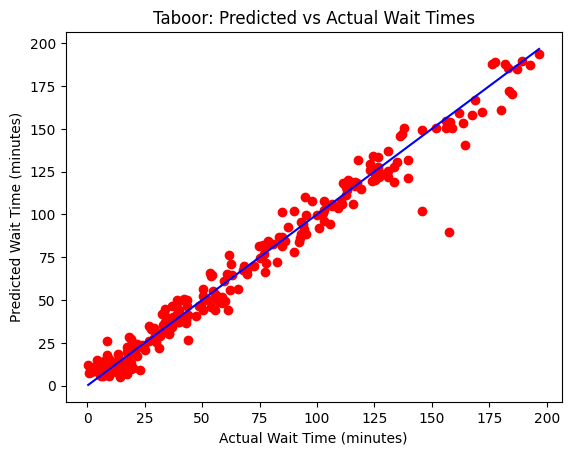

In [42]:
plt.scatter(y_test, stacking_pred, color = 'red')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color = 'blue')
plt.title('Taboor: Predicted vs Actual Wait Times')
plt.xlabel('Actual Wait Time (minutes)')
plt.ylabel('Predicted Wait Time (minutes)')
plt.show()

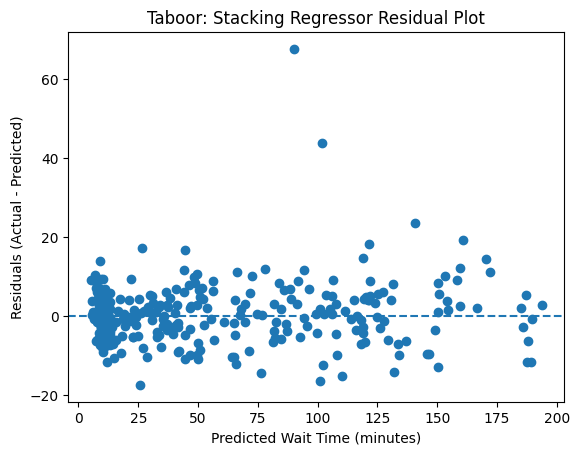

In [43]:
# Residual Plot
residuals = y_test - stacking_pred

plt.scatter(stacking_pred, residuals)
plt.axhline(y=0, linestyle='--')
plt.title('Taboor: Stacking Regressor Residual Plot')
plt.xlabel('Predicted Wait Time (minutes)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.show()

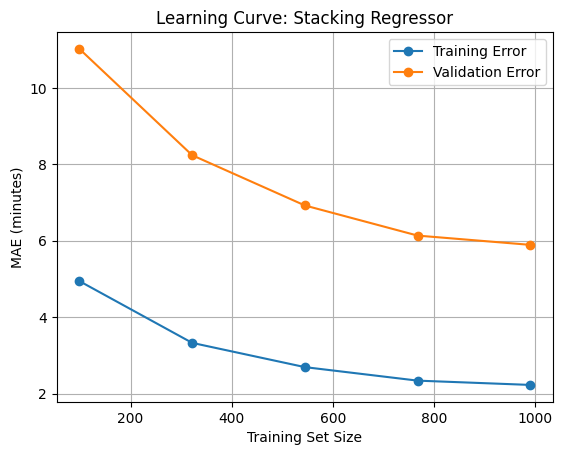

: 

In [ ]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    stacking_model, X_train, y_train,
    cv=5, scoring='neg_mean_absolute_error'
)

train_scores_mean = -train_scores.mean(axis=1)
val_scores_mean = -val_scores.mean(axis=1)

plt.plot(train_sizes, train_scores_mean, marker='o', label='Training Error')
plt.plot(train_sizes, val_scores_mean, marker='o', label='Validation Error')
plt.title('Learning Curve: Stacking Regressor')
plt.xlabel('Training Set Size')
plt.ylabel('MAE (minutes)')
plt.legend()
plt.grid(True)
plt.show()

In [26]:
import os
import joblib

MODEL_PATHS = {
    'stacking': 'models/stacking_model.pkl',
    'transformer': 'models/column_transformer.pkl',
    'scaler': 'models/scaler.pkl'
}

# Check if all models exist
all_exist = all(os.path.exists(path) for path in MODEL_PATHS.values())

if not all_exist:
    print("Training models...")
    # Train and save
    stacking_model.fit(X_train, y_train)
    joblib.dump(stacking_model, MODEL_PATHS['stacking'])
    joblib.dump(ct, MODEL_PATHS['transformer'])
    joblib.dump(sc, MODEL_PATHS['scaler'])
else:
    print("Models already exist, skipping training.")

Models already exist, skipping training.
